DATA LOADED SUCCESSFULLY

Columns:
['GLD', 'SPY', 'TLT', 'VIX']

Shape:
(5467, 4)

Sample period:
2004-11-18 to 2026-08-13

First 5 observations:
                  GLD        SPY        TLT    VIX
Date                                              
2004-11-18  44.380001  79.745277  43.650974  12.98
2004-11-19  44.779999  78.858757  43.302593  13.50
2004-11-22  44.950001  79.234856  43.528294  12.97
2004-11-23  44.750000  79.355743  43.582264  12.67
2004-11-24  45.049999  79.543777  43.582264  12.72

All required columns are present.

RETURNS DATA
Returns sample period: 2004-11-19 to 2026-08-13
Number of observations: 5466

First 5 observations:
                 TLT       GLD       SPY  VIX_change  VIX_logret
Date                                                            
2004-11-19 -0.008013  0.008973 -0.011179    0.520000    0.039280
2004-11-22  0.005199  0.003789  0.004758   -0.530000   -0.040051
2004-11-23  0.001239 -0.004459  0.001525   -0.300000   -0.023402
2004-11-24  0.000000  0

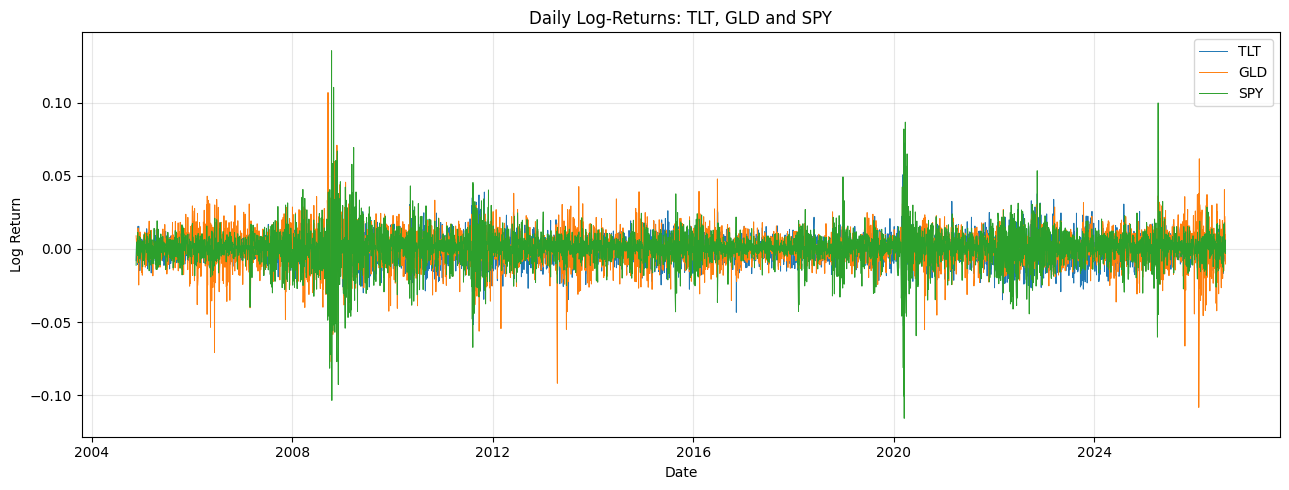

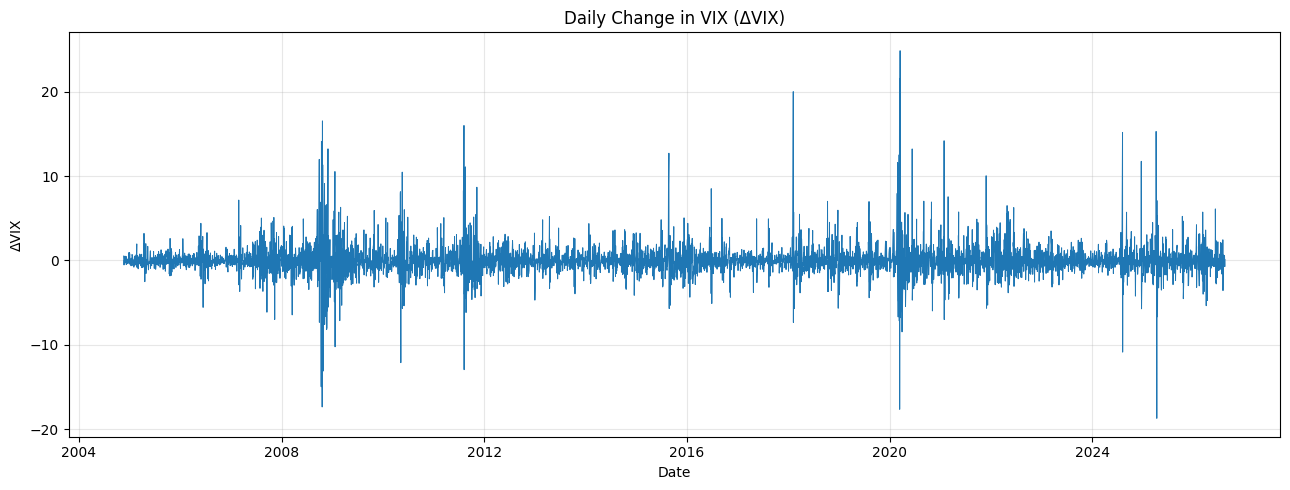


Correlation Matrix:
               TLT     GLD     SPY  VIX_change
TLT         1.0000  0.1554 -0.2972      0.2573
GLD         0.1554  1.0000  0.0658     -0.0546
SPY        -0.2972  0.0658  1.0000     -0.8214
VIX_change  0.2573 -0.0546 -0.8214      1.0000


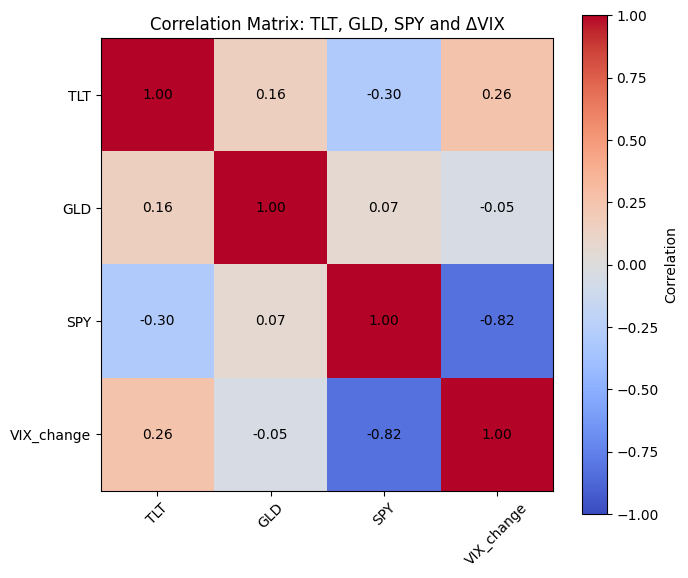


2-STATE MARKOV CHAIN
          Low Vol  High Vol
Low Vol    0.4812    0.5188
High Vol   0.5190    0.4810

Stationary distribution:
[0.5001 0.4999]

3-STATE MARKOV CHAIN
            Low Vol  Medium Vol  High Vol
Low Vol      0.3485      0.3052    0.3463
Medium Vol   0.2349      0.4299    0.3352
High Vol     0.4172      0.2675    0.3154

Stationary distribution:
[0.3334 0.3343 0.3323]

2-STATE HMM
Means: [-0.0747  0.2131]
Variances: [ 0.6556 11.9582]
Log-Likelihood: -9310.96
AIC: 18635.91
BIC: 18682.15

Transition Matrix:
          Low Vol  High Vol
Low Vol    0.9586    0.0414
High Vol   0.1174    0.8826

3-STATE HMM
Means: [-0.0624 -0.0112  0.6529]
Variances: [ 0.3823  3.0976 36.2276]
Log-Likelihood: -8962.97
AIC: 17953.94
BIC: 18046.42

Transition Matrix:
            Low Vol  Medium Vol  High Vol
Low Vol      0.9390      0.0600    0.0010
Medium Vol   0.0747      0.9091    0.0162
High Vol     0.0000      0.1286    0.8714


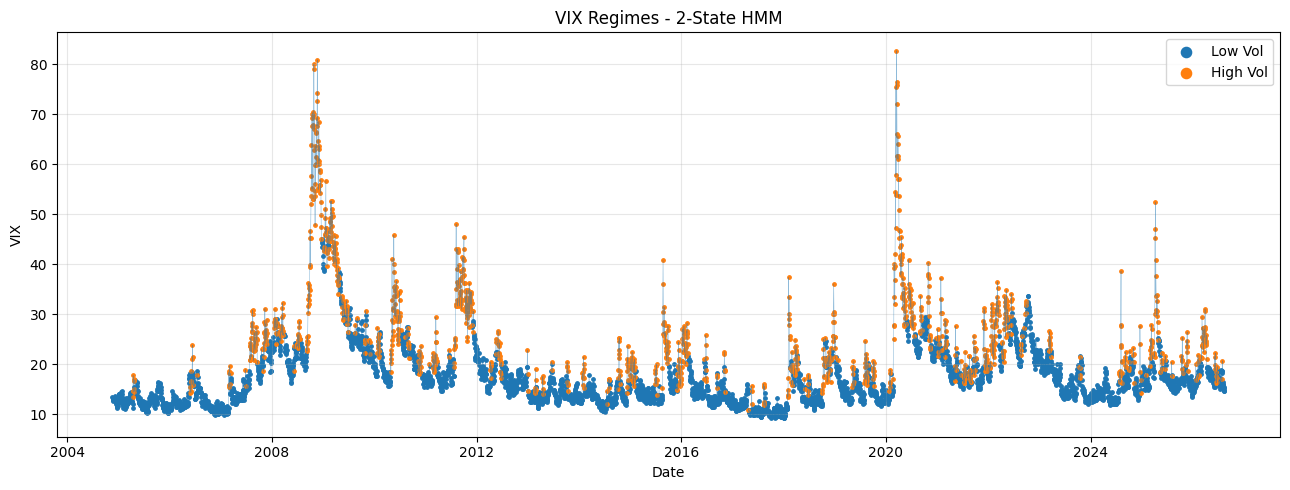

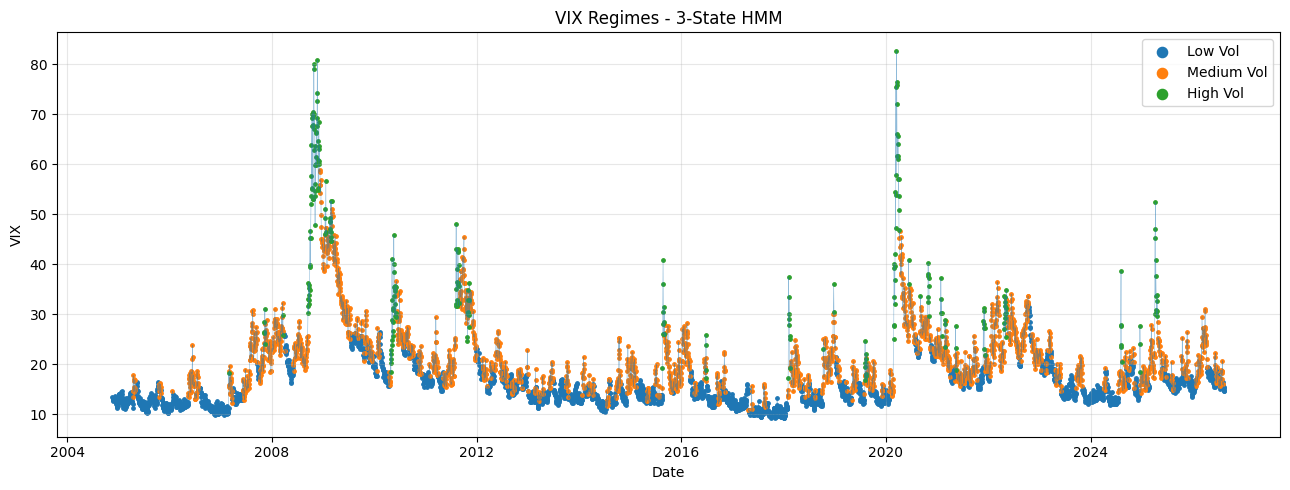


MODEL COMPARISON
             Log-Likelihood       AIC       BIC  Params (k)
2-state HMM        -9310.96  18635.91  18682.15         7.0
3-state HMM        -8962.97  17953.94  18046.42        14.0

MEAN DAILY ETF RETURNS BY REGIME
             TLT       GLD       SPY
Regime                              
0      -0.000165  0.000454  0.001341
1       0.000290  0.000360 -0.000036
2       0.001668  0.000215 -0.005713

STANDARD DEVIATION BY REGIME
             TLT       GLD       SPY
Regime                              
0       0.007430  0.009500  0.005624
1       0.009611  0.012325  0.012330
2       0.017834  0.020455  0.034682


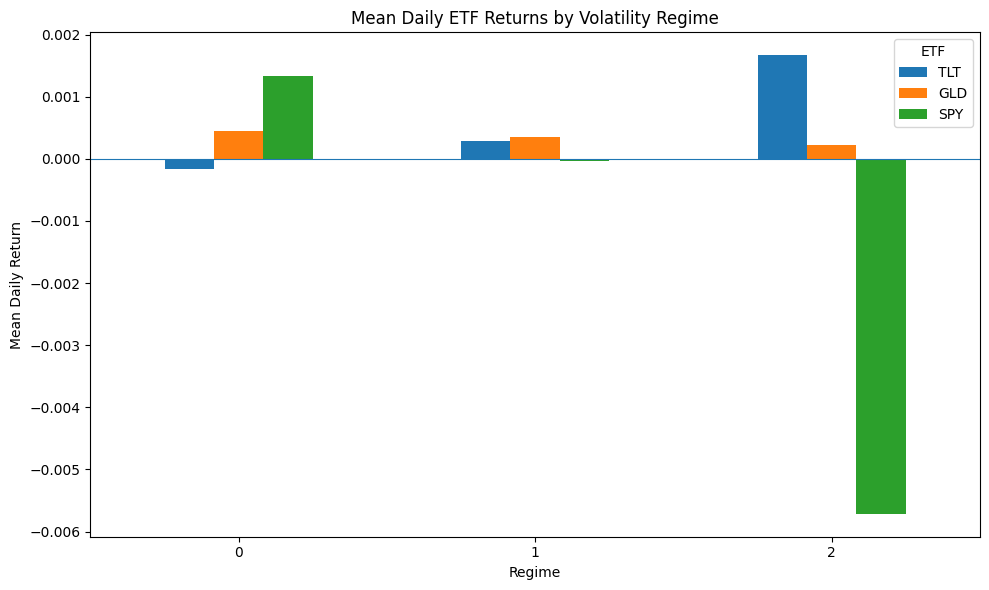

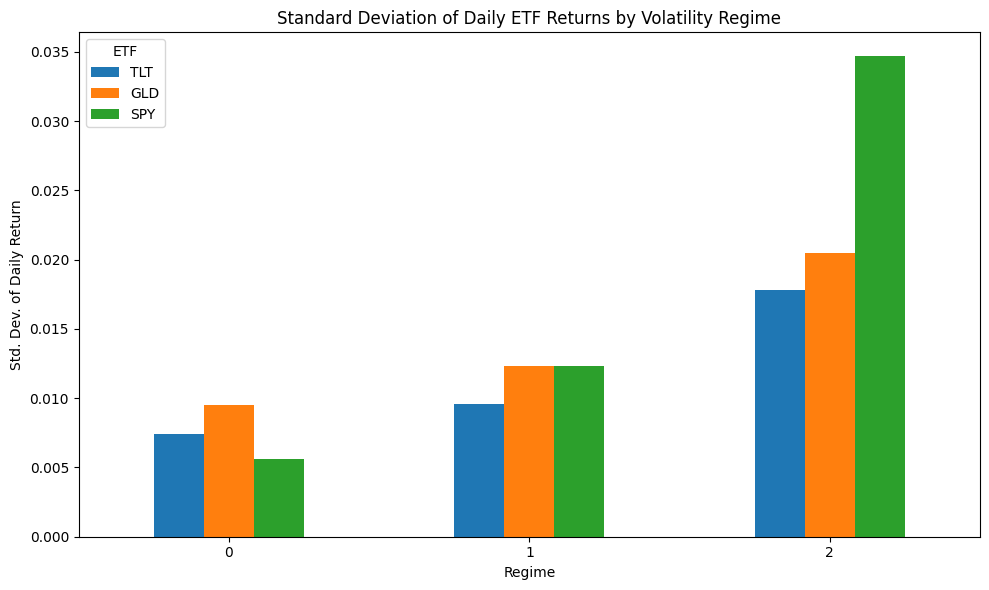


FINAL STATE → ALLOCATION MAPPING
       Allocated ETF (100%)  Mean Daily Return  Std. Dev.
Regime                                                   
0                       SPY           0.001341   0.005624
1                       GLD           0.000360   0.012325
2                       TLT           0.001668   0.017834

ALLOCATION PREVIEW
            Regime Allocation
Date                         
2004-11-19       0        NaN
2004-11-22       0        SPY
2004-11-23       0        SPY
2004-11-24       0        SPY
2004-11-26       0        SPY
2004-11-29       0        SPY
2004-11-30       0        SPY
2004-12-01       0        SPY
2004-12-02       0        SPY
2004-12-03       0        SPY
2004-12-06       0        SPY
2004-12-07       0        SPY
2004-12-08       0        SPY
2004-12-09       0        SPY
2004-12-10       0        SPY
2004-12-13       0        SPY
2004-12-14       0        SPY
2004-12-15       0        SPY
2004-12-16       0        SPY
2004-12-17       0        

In [1]:
# ================================================================
# QUANTITATIVE REGIME-BASED ALLOCATION STRATEGY
# STEPS 1–4
# TLT, GLD, SPY and VIX
# ================================================================

# ================================================================
# STEP 1: DATA PREPARATION AND EXPLORATION
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. Load data
# ------------------------------------------------

file_path = "DATA.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["Date"],
    index_col="Date",
    dayfirst=True
)

df = df.sort_index()

print("=" * 70)
print("DATA LOADED SUCCESSFULLY")
print("=" * 70)

print("\nColumns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nSample period:")
print(df.index.min().date(), "to", df.index.max().date())

print("\nFirst 5 observations:")
print(df.head())


# ------------------------------------------------
# 2. Check required columns
# ------------------------------------------------

required_columns = ["GLD", "SPY", "TLT", "VIX"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nAll required columns are present.")


# ================================================================
# STEP 1.2: CALCULATE RETURNS
# ================================================================

etf_cols = ["TLT", "GLD", "SPY"]

# Daily ETF log returns
log_returns = np.log(
    df[etf_cols] / df[etf_cols].shift(1)
)

# VIX change
vix_change = df["VIX"].diff()

# VIX log return
vix_log_return = np.log(
    df["VIX"] / df["VIX"].shift(1)
)

# Combine
returns = log_returns.copy()

returns["VIX_change"] = vix_change
returns["VIX_logret"] = vix_log_return

# Remove missing values
returns = returns.dropna()

print("\n" + "=" * 70)
print("RETURNS DATA")
print("=" * 70)

print(
    f"Returns sample period: "
    f"{returns.index.min().date()} to "
    f"{returns.index.max().date()}"
)

print("Number of observations:", len(returns))

print("\nFirst 5 observations:")
print(returns.head())


# ================================================================
# STEP 1.3: ETF RETURN PLOT
# ================================================================

plt.figure(figsize=(13, 5))

for col in etf_cols:
    plt.plot(
        returns.index,
        returns[col],
        label=col,
        linewidth=0.7
    )

plt.title("Daily Log-Returns: TLT, GLD and SPY")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "step1_etf_returns.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# STEP 1.4: VIX CHANGE PLOT
# ================================================================

plt.figure(figsize=(13, 5))

plt.plot(
    returns.index,
    returns["VIX_change"],
    linewidth=0.7
)

plt.title("Daily Change in VIX (ΔVIX)")
plt.xlabel("Date")
plt.ylabel("ΔVIX")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "step1_vix_change.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# STEP 1.5: CORRELATION MATRIX
# ================================================================

corr = returns[
    ["TLT", "GLD", "SPY", "VIX_change"]
].corr()

print("\nCorrelation Matrix:")
print(corr.round(4))

plt.figure(figsize=(7, 6))

plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.index)),
    corr.index
)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix: TLT, GLD, SPY and ΔVIX")
plt.tight_layout()

plt.savefig(
    "step1_correlation_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# STEP 2: MODELING VIX REGIMES
# ================================================================

dvix = returns["VIX_change"]

# VIX level corresponding to return dates
vix_level = df.loc[
    returns.index,
    "VIX"
]


# ================================================================
# STEP 2A: DISCRETE MARKOV CHAIN
# ================================================================

def get_states(series, n):

    edges = series.quantile(
        np.linspace(0, 1, n + 1)
    ).values

    edges[0] = -np.inf
    edges[-1] = np.inf

    return pd.cut(
        series,
        bins=edges,
        labels=False,
        include_lowest=True
    )


def transition_matrix(states, n):

    counts = np.zeros((n, n))

    s = states.values

    for t in range(len(s) - 1):

        counts[
            s[t],
            s[t + 1]
        ] += 1

    return counts / counts.sum(
        axis=1,
        keepdims=True
    )


def stationary_dist(P):

    vals, vecs = np.linalg.eig(P.T)

    pi = np.real(
        vecs[
            :,
            np.argmin(
                np.abs(vals - 1)
            )
        ]
    )

    return pi / pi.sum()


# ------------------------------------------------
# 2-state Markov Chain
# ------------------------------------------------

states2 = get_states(
    dvix,
    2
)

P2 = transition_matrix(
    states2,
    2
)

pi2 = stationary_dist(P2)

labels2 = [
    "Low Vol",
    "High Vol"
]

print("\n" + "=" * 70)
print("2-STATE MARKOV CHAIN")
print("=" * 70)

print(
    pd.DataFrame(
        P2,
        index=labels2,
        columns=labels2
    ).round(4)
)

print("\nStationary distribution:")
print(pi2.round(4))


# ------------------------------------------------
# 3-state Markov Chain
# ------------------------------------------------

states3 = get_states(
    dvix,
    3
)

P3 = transition_matrix(
    states3,
    3
)

pi3 = stationary_dist(P3)

labels3 = [
    "Low Vol",
    "Medium Vol",
    "High Vol"
]

print("\n" + "=" * 70)
print("3-STATE MARKOV CHAIN")
print("=" * 70)

print(
    pd.DataFrame(
        P3,
        index=labels3,
        columns=labels3
    ).round(4)
)

print("\nStationary distribution:")
print(pi3.round(4))


# ================================================================
# STEP 2B: HIDDEN MARKOV MODEL
# ================================================================

# Install if necessary
try:

    from hmmlearn.hmm import GaussianHMM

except ModuleNotFoundError:

    import sys
    import subprocess

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "hmmlearn",
            "-q"
        ]
    )

    from hmmlearn.hmm import GaussianHMM


# ------------------------------------------------
# HMM function
# ------------------------------------------------

def fit_hmm(series, n, seed=42):

    X = series.values.reshape(-1, 1)

    model = GaussianHMM(
        n_components=n,
        covariance_type="full",
        n_iter=1000,
        random_state=seed
    )

    model.fit(X)

    means = model.means_.flatten()

    order = np.argsort(means)

    remap = {
        old: new
        for new, old in enumerate(order)
    }

    states_raw = model.predict(X)

    probs_raw = model.predict_proba(X)

    states = np.array(
        [
            remap[s]
            for s in states_raw
        ]
    )

    probs = probs_raw[:, order]

    trans = model.transmat_[
        order
    ][:, order]

    ll = model.score(X)

    k = (
        n * (n - 1)
        + 2 * n
        + (n - 1)
    )

    aic = -2 * ll + 2 * k

    bic = (
        -2 * ll
        + k * np.log(len(X))
    )

    return {
        "model": model,
        "states": states,
        "probs": probs,
        "trans": trans,
        "means": means[order],
        "vars": model.covars_.flatten()[order],
        "ll": ll,
        "k": k,
        "aic": aic,
        "bic": bic
    }


# ------------------------------------------------
# Fit 2-state HMM
# ------------------------------------------------

hmm2 = fit_hmm(
    dvix,
    2
)


# ------------------------------------------------
# Fit 3-state HMM
# ------------------------------------------------

hmm3 = fit_hmm(
    dvix,
    3
)


# ------------------------------------------------
# Display HMM results
# ------------------------------------------------

for name, h, labels in [
    ("2-state", hmm2, labels2),
    ("3-state", hmm3, labels3)
]:

    print("\n" + "=" * 70)
    print(name.upper(), "HMM")
    print("=" * 70)

    print(
        "Means:",
        h["means"].round(4)
    )

    print(
        "Variances:",
        h["vars"].round(4)
    )

    print(
        f"Log-Likelihood: {h['ll']:.2f}"
    )

    print(
        f"AIC: {h['aic']:.2f}"
    )

    print(
        f"BIC: {h['bic']:.2f}"
    )

    print("\nTransition Matrix:")

    print(
        pd.DataFrame(
            h["trans"],
            index=labels,
            columns=labels
        ).round(4)
    )


# ================================================================
# STEP 2C: HMM REGIME PLOTS
# ================================================================

def plot_states(
    vix,
    states,
    labels,
    title
):

    plt.figure(figsize=(13, 5))

    for i in range(len(labels)):

        mask = states == i

        plt.scatter(
            vix.index[mask],
            vix[mask],
            s=6,
            label=labels[i]
        )

    plt.plot(
        vix.index,
        vix.values,
        linewidth=0.4,
        alpha=0.5
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("VIX")

    plt.legend(
        markerscale=3
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


plot_states(
    vix_level,
    hmm2["states"],
    labels2,
    "VIX Regimes - 2-State HMM"
)

plot_states(
    vix_level,
    hmm3["states"],
    labels3,
    "VIX Regimes - 3-State HMM"
)


# ================================================================
# STEP 3: MODEL SELECTION
# ================================================================

comparison = pd.DataFrame({

    "2-state HMM": {
        "Log-Likelihood": hmm2["ll"],
        "AIC": hmm2["aic"],
        "BIC": hmm2["bic"],
        "Params (k)": hmm2["k"]
    },

    "3-state HMM": {
        "Log-Likelihood": hmm3["ll"],
        "AIC": hmm3["aic"],
        "BIC": hmm3["bic"],
        "Params (k)": hmm3["k"]
    }

}).T

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    comparison.round(2)
)


# ================================================================
# SELECT 3-STATE HMM
# ================================================================

# This follows the team's Step 3 conclusion
returns["Regime"] = hmm3["states"]


# ================================================================
# STEP 3.2: ETF PERFORMANCE BY REGIME
# ================================================================

mean_returns = returns.groupby(
    "Regime"
)[
    ["TLT", "GLD", "SPY"]
].mean()

print("\n" + "=" * 70)
print("MEAN DAILY ETF RETURNS BY REGIME")
print("=" * 70)

print(
    mean_returns
)


# ================================================================
# STEP 3.3: ETF RISK BY REGIME
# ================================================================

std_returns = returns.groupby(
    "Regime"
)[
    ["TLT", "GLD", "SPY"]
].std()

print("\n" + "=" * 70)
print("STANDARD DEVIATION BY REGIME")
print("=" * 70)

print(
    std_returns
)


# ================================================================
# STEP 3.4: MEAN RETURN BAR CHART
# ================================================================

ax = mean_returns.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Mean Daily ETF Returns by Volatility Regime"
)

plt.xlabel("Regime")
plt.ylabel("Mean Daily Return")

plt.xticks(
    rotation=0
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.legend(
    title="ETF"
)

plt.tight_layout()

plt.savefig(
    "step3_mean_returns_by_regime.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# STEP 3.5: STANDARD DEVIATION BAR CHART
# ================================================================

ax = std_returns.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Standard Deviation of Daily ETF Returns by Volatility Regime"
)

plt.xlabel("Regime")
plt.ylabel("Std. Dev. of Daily Return")

plt.xticks(
    rotation=0
)

plt.legend(
    title="ETF"
)

plt.tight_layout()

plt.savefig(
    "step3_std_returns_by_regime.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# STEP 4: DESIGNING THE ROTATION STRATEGY
# ================================================================

# Identify ETF with highest historical mean return
# in each regime.

best_asset_by_regime = (
    mean_returns.idxmax(axis=1)
)

allocation_map = (
    best_asset_by_regime.to_dict()
)


# ------------------------------------------------
# State -> Allocation table
# ------------------------------------------------

alloc_table = pd.DataFrame({

    "Regime": list(
        allocation_map.keys()
    ),

    "Allocated ETF (100%)": list(
        allocation_map.values()
    ),

    "Mean Daily Return": [
        mean_returns.loc[
            r,
            allocation_map[r]
        ]
        for r in allocation_map
    ],

    "Std. Dev.": [
        std_returns.loc[
            r,
            allocation_map[r]
        ]
        for r in allocation_map
    ]

}).set_index("Regime")


print("\n" + "=" * 70)
print("FINAL STATE → ALLOCATION MAPPING")
print("=" * 70)

print(
    alloc_table
)


# ================================================================
# 1-DAY EXECUTION LAG
# ================================================================

returns["Allocation"] = (
    returns["Regime"]
    .shift(1)
    .map(allocation_map)
)


print("\n" + "=" * 70)
print("ALLOCATION PREVIEW")
print("=" * 70)

print(
    returns[
        ["Regime", "Allocation"]
    ].head(20)
)


# ================================================================
# SAVE STEPS 1–4 DATA
# ================================================================

returns.to_csv(
    "steps1_to_4_returns_with_regimes.csv"
)

alloc_table.to_csv(
    "step4_allocation_mapping.csv"
)

comparison.to_csv(
    "step3_model_comparison.csv"
)

print("\nSteps 1–4 completed successfully.")

STEP 5: BACKTESTING AND EVALUATION

Backtest period:
2004-11-22 to 2026-08-13

Number of trading days: 5465

PERFORMANCE SUMMARY
                         Cumulative Return  Annualized Return  \
Regime-Based Strategy              3163.75              17.44   
Equal-Weight (1/3 Each)             397.08               7.67   
Buy-and-Hold SPY                    568.14               9.15   

                         Annualized Volatility  Sharpe Ratio  Max Drawdown  
Regime-Based Strategy                    15.51          1.12        -24.45  
Equal-Weight (1/3 Each)                   9.81          0.78        -23.99  
Buy-and-Hold SPY                         18.89          0.48        -59.58  


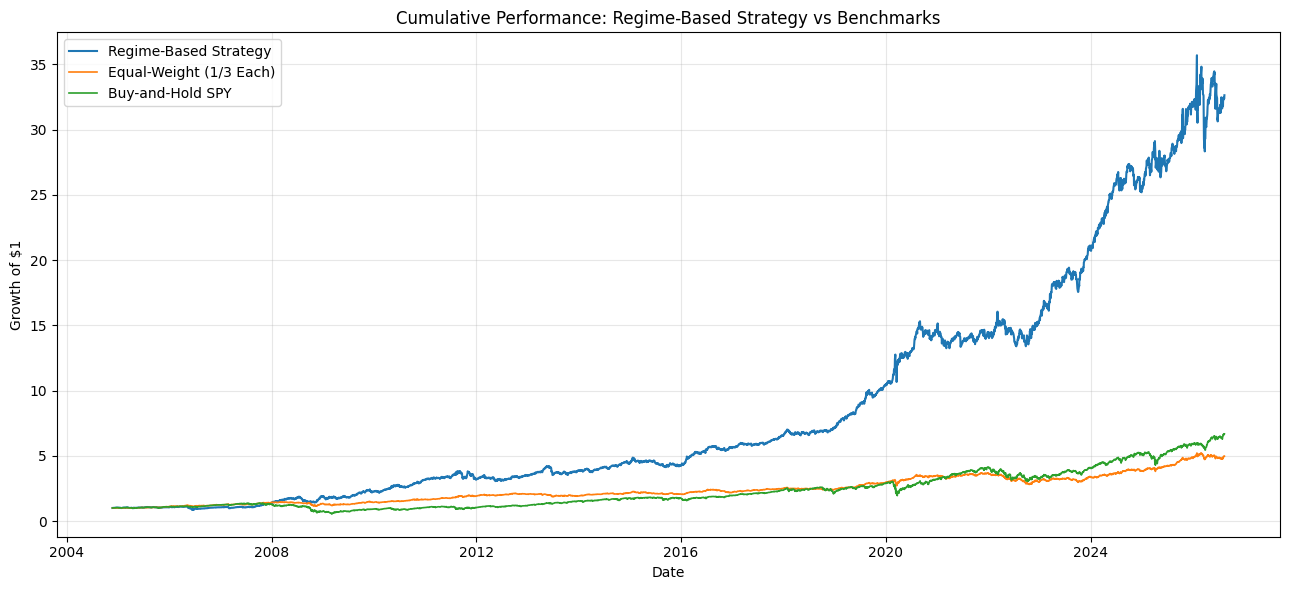

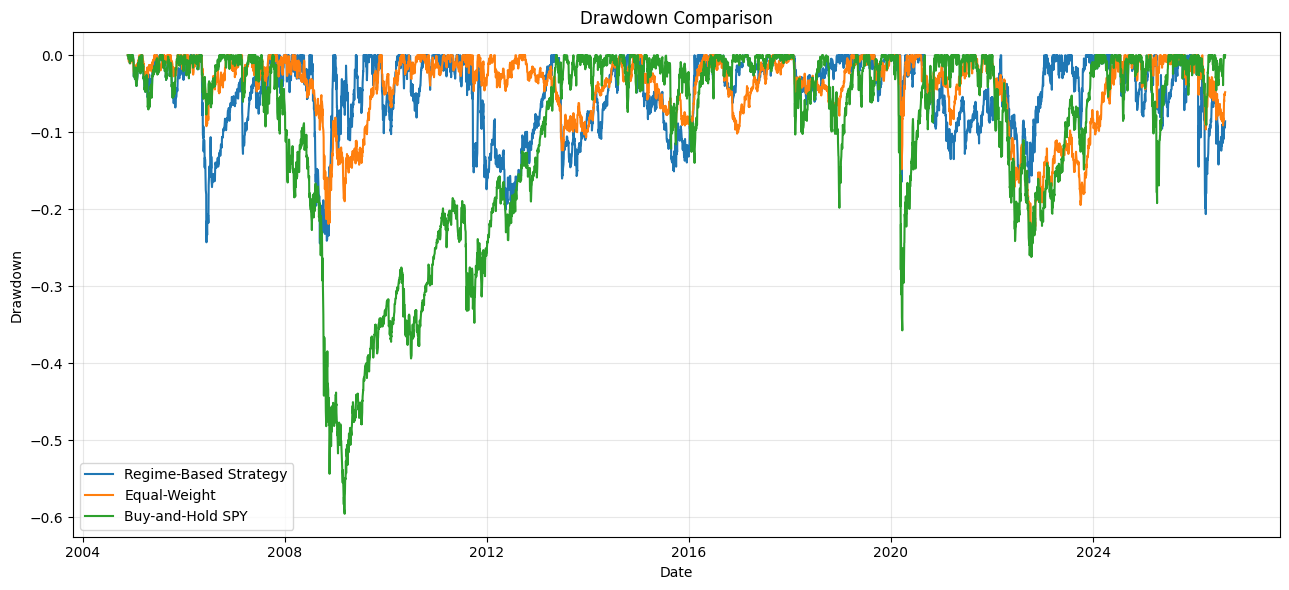


STEP 5 COMPLETED SUCCESSFULLY

Performance Summary:
                         Cumulative Return  Annualized Return  \
Regime-Based Strategy              3163.75              17.44   
Equal-Weight (1/3 Each)             397.08               7.67   
Buy-and-Hold SPY                    568.14               9.15   

                         Annualized Volatility  Sharpe Ratio  Max Drawdown  
Regime-Based Strategy                    15.51          1.12        -24.45  
Equal-Weight (1/3 Each)                   9.81          0.78        -23.99  
Buy-and-Hold SPY                         18.89          0.48        -59.58  

Files saved:
1. step5_backtest_results.csv
2. step5_performance_summary.csv
3. step5_cumulative_performance.png
4. step5_drawdown_comparison.png


In [3]:
# ================================================================
# STEP 5: BACKTESTING AND EVALUATION
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ================================================================
# 5.1 PREPARE BACKTEST DATA
# ================================================================

bt = returns[
    ["TLT", "GLD", "SPY", "Regime", "Allocation"]
].copy()

# Remove first observation because of 1-day execution lag
bt = bt.dropna(
    subset=["Allocation"]
).copy()

print("=" * 70)
print("STEP 5: BACKTESTING AND EVALUATION")
print("=" * 70)

print("\nBacktest period:")
print(
    bt.index.min().date(),
    "to",
    bt.index.max().date()
)

print(
    "\nNumber of trading days:",
    len(bt)
)


# ================================================================
# 5.2 REGIME-BASED STRATEGY RETURNS
# ================================================================

bt["Strategy_Return"] = np.nan

for asset in ["TLT", "GLD", "SPY"]:

    mask = (
        bt["Allocation"] == asset
    )

    bt.loc[
        mask,
        "Strategy_Return"
    ] = bt.loc[
        mask,
        asset
    ]

bt = bt.dropna(
    subset=["Strategy_Return"]
)


# ================================================================
# 5.3 EQUAL-WEIGHT BENCHMARK
# ================================================================

# 1/3 TLT + 1/3 GLD + 1/3 SPY

bt["Month"] = bt.index.to_period("M")

bt["Equal_Weight_Return"] = (
    bt["TLT"]
    + bt["GLD"]
    + bt["SPY"]
) / 3


# ================================================================
# 5.4 BUY-AND-HOLD SPY
# ================================================================

bt["SPY_Return"] = bt["SPY"]


# ================================================================
# 5.5 CUMULATIVE RETURNS
# ================================================================

bt["Strategy_Cumulative"] = (
    1 + bt["Strategy_Return"]
).cumprod()

bt["Equal_Weight_Cumulative"] = (
    1 + bt["Equal_Weight_Return"]
).cumprod()

bt["SPY_Cumulative"] = (
    1 + bt["SPY_Return"]
).cumprod()


# ================================================================
# 5.6 PERFORMANCE METRICS FUNCTION
# ================================================================

def performance_metrics(
    daily_returns
):

    daily_returns = (
        daily_returns
        .dropna()
    )

    n = len(
        daily_returns
    )

    # Cumulative return
    cumulative_return = (
        (1 + daily_returns).prod()
        - 1
    )

    # Annualized return
    annualized_return = (
        (1 + cumulative_return)
        ** (252 / n)
        - 1
    )

    # Annualized volatility
    annualized_volatility = (
        daily_returns.std()
        * np.sqrt(252)
    )

    # Sharpe ratio
    # Assuming zero risk-free rate,
    # consistent with the project framework.
    sharpe_ratio = (
        annualized_return
        / annualized_volatility
    )

    # Wealth index
    wealth = (
        1 + daily_returns
    ).cumprod()

    # Running maximum
    running_max = (
        wealth.cummax()
    )

    # Drawdown
    drawdown = (
        wealth / running_max
        - 1
    )

    # Maximum drawdown
    max_drawdown = (
        drawdown.min()
    )

    return {
        "Cumulative Return":
            cumulative_return,

        "Annualized Return":
            annualized_return,

        "Annualized Volatility":
            annualized_volatility,

        "Sharpe Ratio":
            sharpe_ratio,

        "Max Drawdown":
            max_drawdown
    }


# ================================================================
# 5.7 CALCULATE PERFORMANCE
# ================================================================

strategy_metrics = performance_metrics(
    bt["Strategy_Return"]
)

equal_weight_metrics = performance_metrics(
    bt["Equal_Weight_Return"]
)

spy_metrics = performance_metrics(
    bt["SPY_Return"]
)


# ================================================================
# 5.8 PERFORMANCE SUMMARY TABLE
# ================================================================

performance_table = pd.DataFrame({

    "Regime-Based Strategy":
        strategy_metrics,

    "Equal-Weight (1/3 Each)":
        equal_weight_metrics,

    "Buy-and-Hold SPY":
        spy_metrics

}).T


print("\n" + "=" * 70)
print("PERFORMANCE SUMMARY")
print("=" * 70)

# Display percentages
performance_display = (
    performance_table.copy()
)

percentage_columns = [
    "Cumulative Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown"
]

for col in percentage_columns:

    performance_display[col] = (
        performance_display[col]
        * 100
    )

print(
    performance_display.round(2)
)


# ================================================================
# 5.9 CUMULATIVE PERFORMANCE PLOT
# ================================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    bt.index,
    bt["Strategy_Cumulative"],
    label="Regime-Based Strategy",
    linewidth=1.5
)

plt.plot(
    bt.index,
    bt["Equal_Weight_Cumulative"],
    label="Equal-Weight (1/3 Each)",
    linewidth=1.2
)

plt.plot(
    bt.index,
    bt["SPY_Cumulative"],
    label="Buy-and-Hold SPY",
    linewidth=1.2
)

plt.title(
    "Cumulative Performance: Regime-Based Strategy vs Benchmarks"
)

plt.xlabel("Date")

plt.ylabel(
    "Growth of $1"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "step5_cumulative_performance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 5.10 DRAWDOWN ANALYSIS
# ================================================================

def calculate_drawdown(
    daily_returns
):

    wealth = (
        1 + daily_returns
    ).cumprod()

    running_max = (
        wealth.cummax()
    )

    return (
        wealth / running_max
        - 1
    )


bt["Strategy_Drawdown"] = (
    calculate_drawdown(
        bt["Strategy_Return"]
    )
)

bt["Equal_Weight_Drawdown"] = (
    calculate_drawdown(
        bt["Equal_Weight_Return"]
    )
)

bt["SPY_Drawdown"] = (
    calculate_drawdown(
        bt["SPY_Return"]
    )
)


# ================================================================
# DRAWDOWN PLOT
# ================================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    bt.index,
    bt["Strategy_Drawdown"],
    label="Regime-Based Strategy"
)

plt.plot(
    bt.index,
    bt["Equal_Weight_Drawdown"],
    label="Equal-Weight"
)

plt.plot(
    bt.index,
    bt["SPY_Drawdown"],
    label="Buy-and-Hold SPY"
)

plt.title(
    "Drawdown Comparison"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "step5_drawdown_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 5.11 SAVE BACKTEST RESULTS
# ================================================================

bt.to_csv(
    "step5_backtest_results.csv"
)

performance_display.to_csv(
    "step5_performance_summary.csv"
)


# ================================================================
# FINAL OUTPUT
# ================================================================

print("\n" + "=" * 70)
print("STEP 5 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nPerformance Summary:")
print(
    performance_display.round(2)
)

print("\nFiles saved:")
print(
    "1. step5_backtest_results.csv"
)

print(
    "2. step5_performance_summary.csv"
)

print(
    "3. step5_cumulative_performance.png"
)

print(
    "4. step5_drawdown_comparison.png"
)